# Comparison with decision tree and bagging

In [1]:
# Disable warnings in Anaconda
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 10, 6
%config InlineBackend.figure_format = 'retina'

import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor,
                              RandomForestClassifier, RandomForestRegressor)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

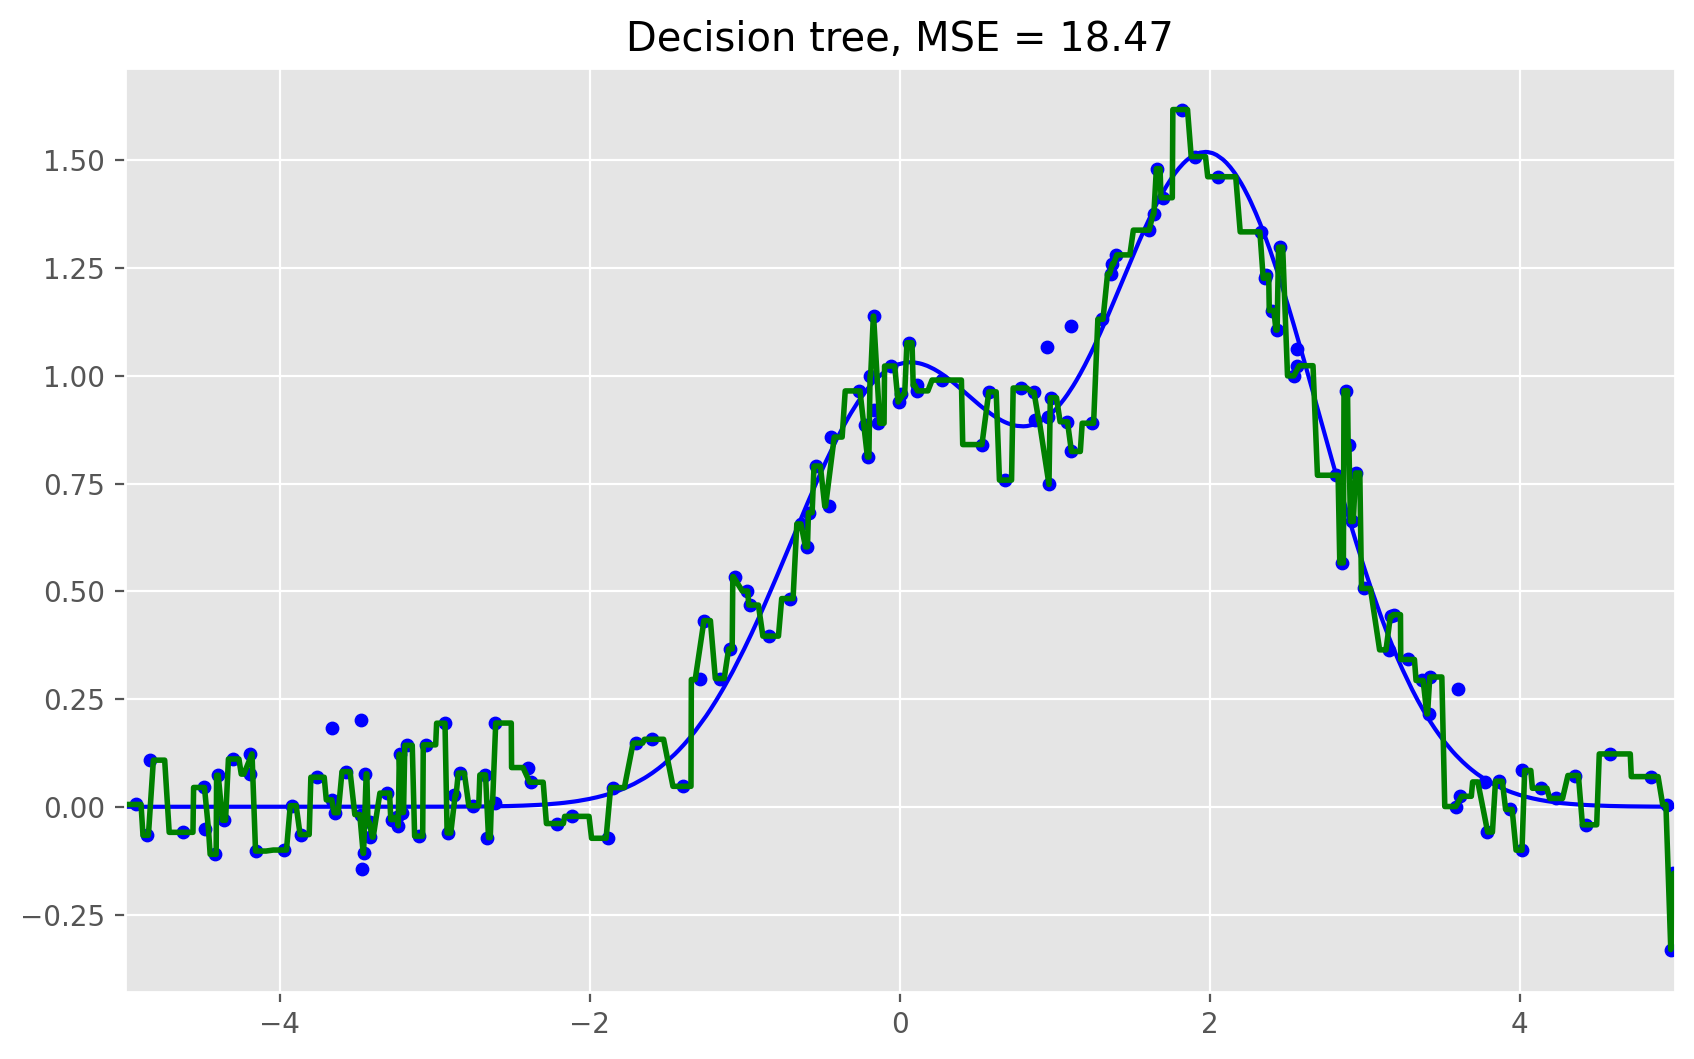

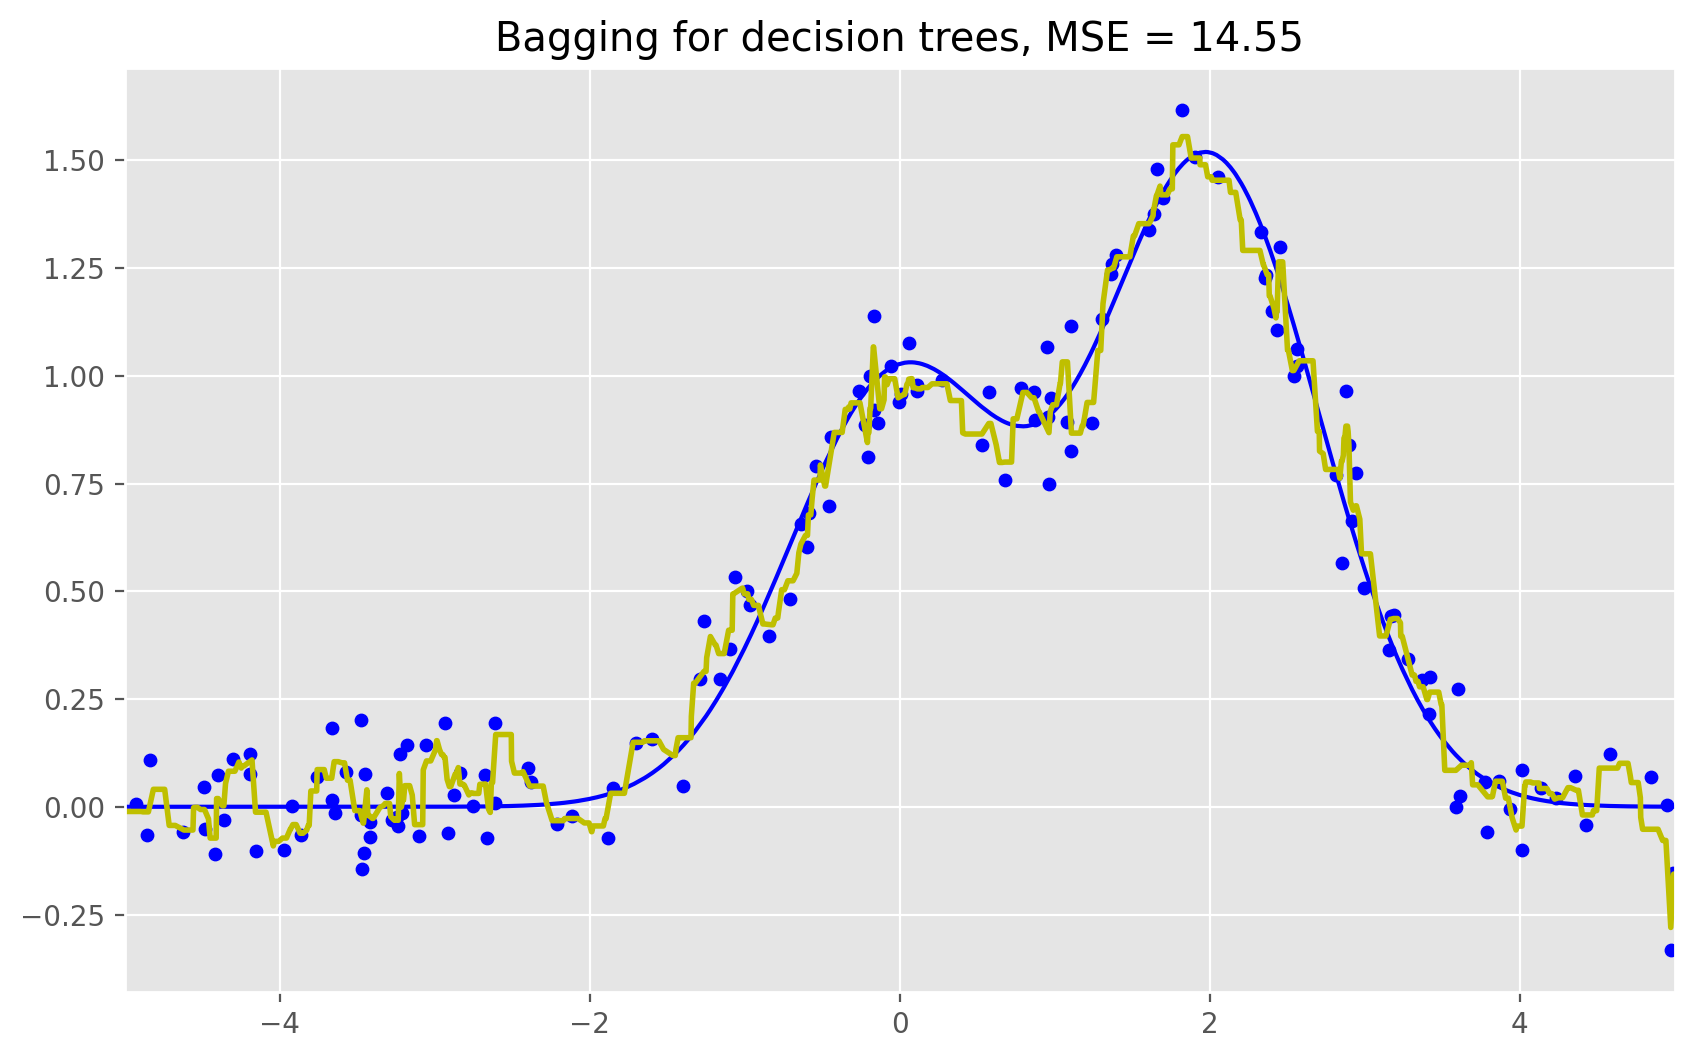

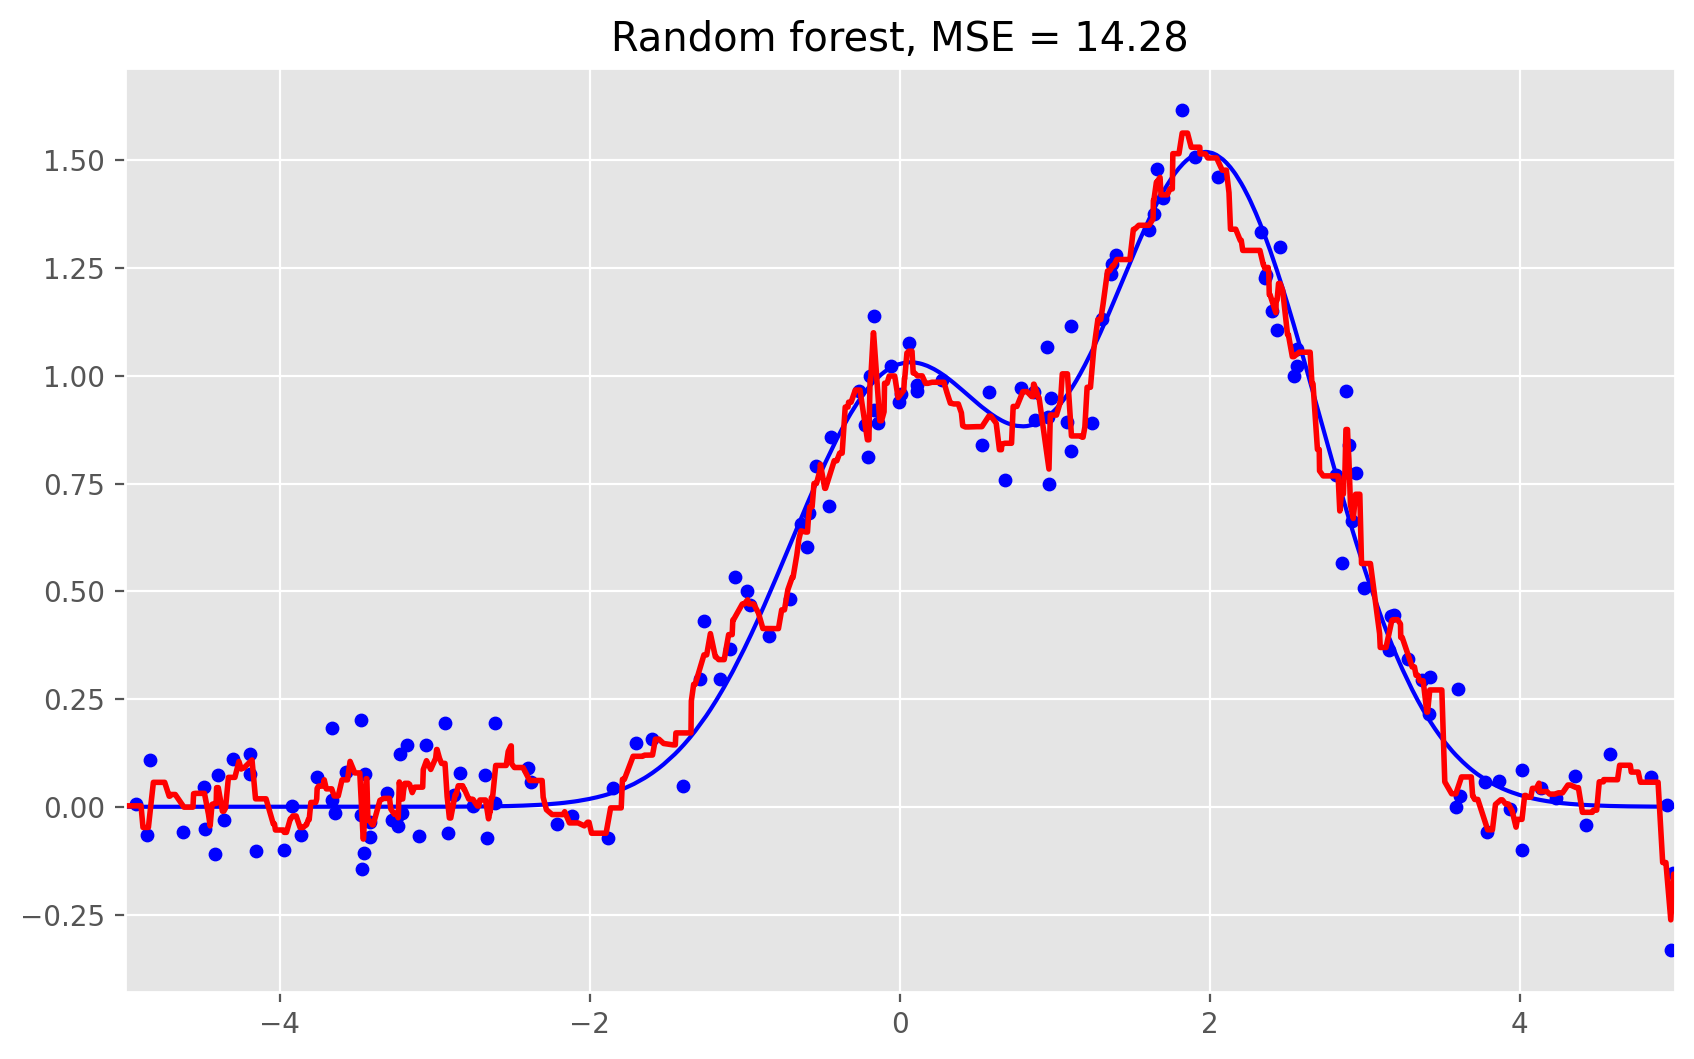

In [2]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
# this function is the sum of two gaussian curves, creates two peakes
# function just to visualize the target points
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x-2) ** 2)

def generate(n_samples, noise):
    # creates values between -5 and 5
    X = np.random.rand(n_samples) * 10 - 5 
    X = np.sort(X).ravel()
    # Create target variables similar to f(x), \ in python says the code is not over - it continues in the next line
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    # y = f(X) + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1)) 

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

# One decision tree regressor
dtree = DecisionTreeRegressor().fit(X_train,y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - d_predict) ** 2))
# simple observation - the predicted green line and the scatter blue dots are lying too closely, also not 
# smooth as the blue line. so we may conclude it may due to overfitting

# bagging with a decision tree regressor
bdt = BaggingRegressor(DecisionTreeRegressor()).fit(X_train,y_train)
bdt_predict = bdt.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, bdt_predict, "y", lw=2)
plt.xlim([-5, 5])
plt.title("Bagging for decision trees, MSE = %.2f" % np.sum((y_test - bdt_predict) ** 2))

# Random forest
rf = RandomForestRegressor(n_estimators=10).fit(X_train, y_train)
rf_predict = rf.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(X_test, f(X_test), "b")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "r", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));


As we can see from our graphs and the MSE values above, a random forest of 10 trees achieves a better result than a single decision tree and is comparable to bagging with 10 trees. The main difference between random forests and bagging is that, in a random forest, the best feature for a split is selected from a random subset of the available features while, in bagging, all features are considered for the next best split.

### Advantages of bagging and random forests in classification problem

In [3]:
X_range = np.linspace(1,10,10)
xx1, xx2 = np.meshgrid(X_range, X_range) # creates grid that can be used as points
y_hat = np.c_[xx1.ravel(), xx2.ravel()]
df = pd.DataFrame({
    "xx1": xx1.ravel(),
    "xx2" : xx2.ravel()
})
df.head(), y_hat[0:5,:]
# np.c_[xx1.ravel(), xx2.ravel()]

(   xx1  xx2
 0  1.0  1.0
 1  2.0  1.0
 2  3.0  1.0
 3  4.0  1.0
 4  5.0  1.0,
 array([[1., 1.],
        [2., 1.],
        [3., 1.],
        [4., 1.],
        [5., 1.]]))

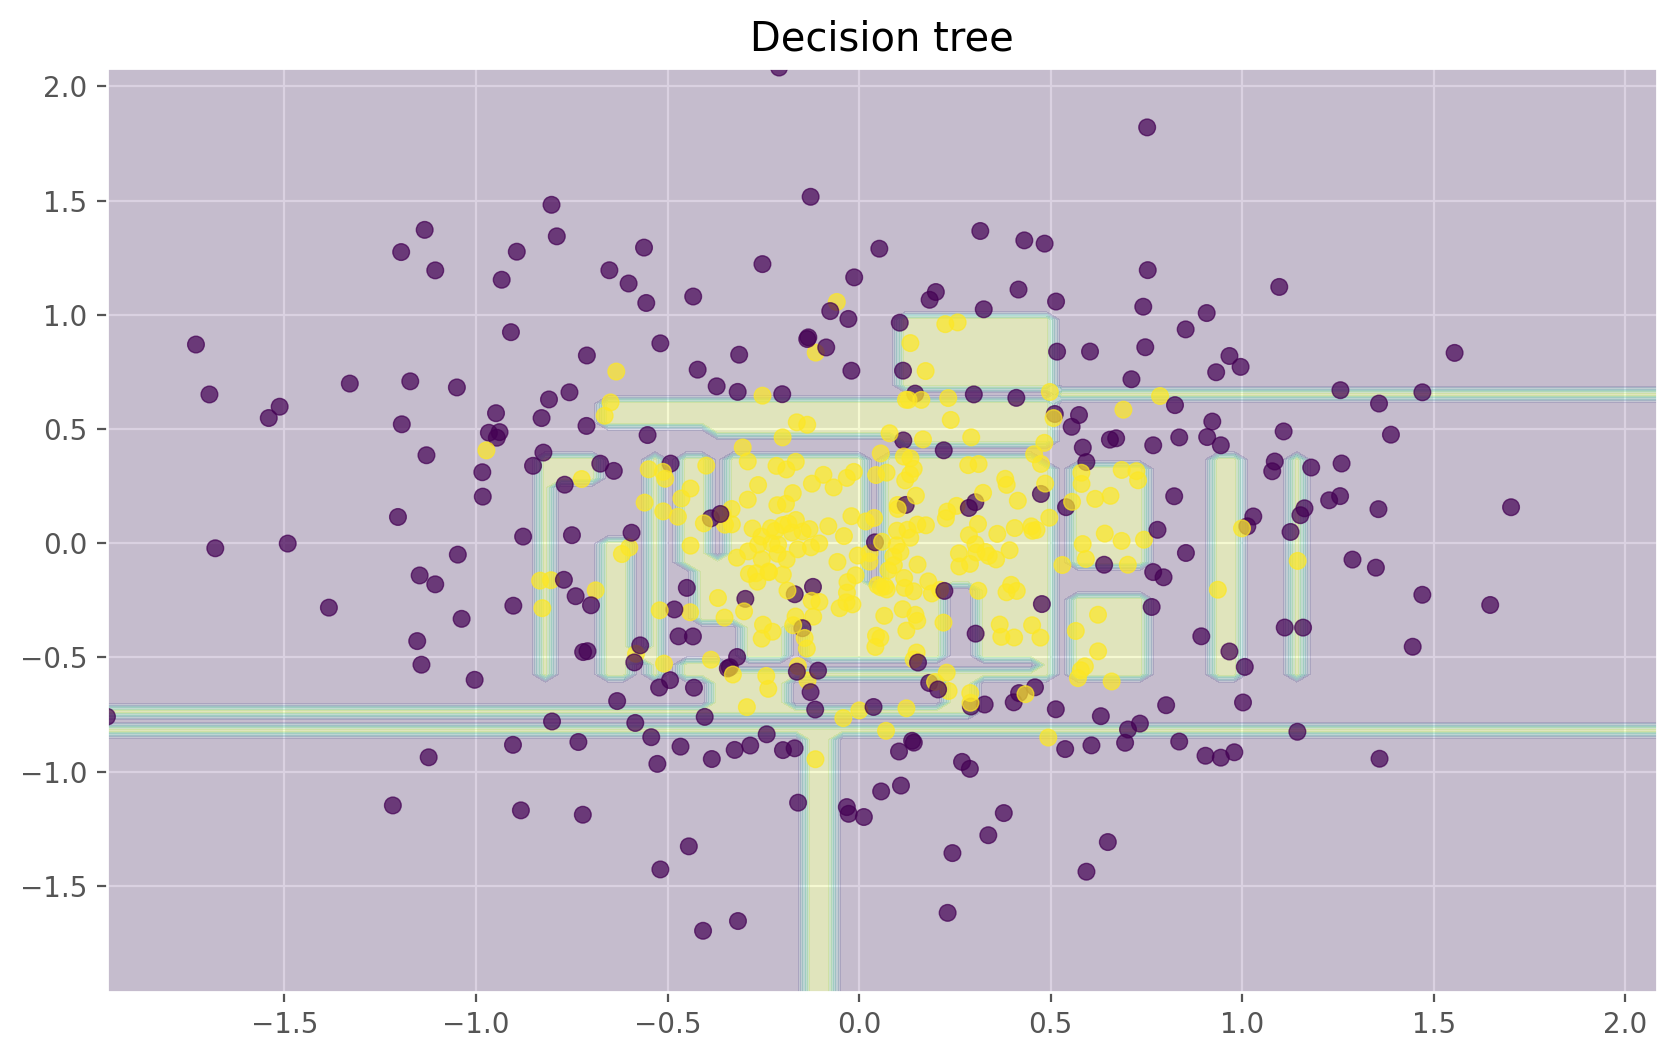

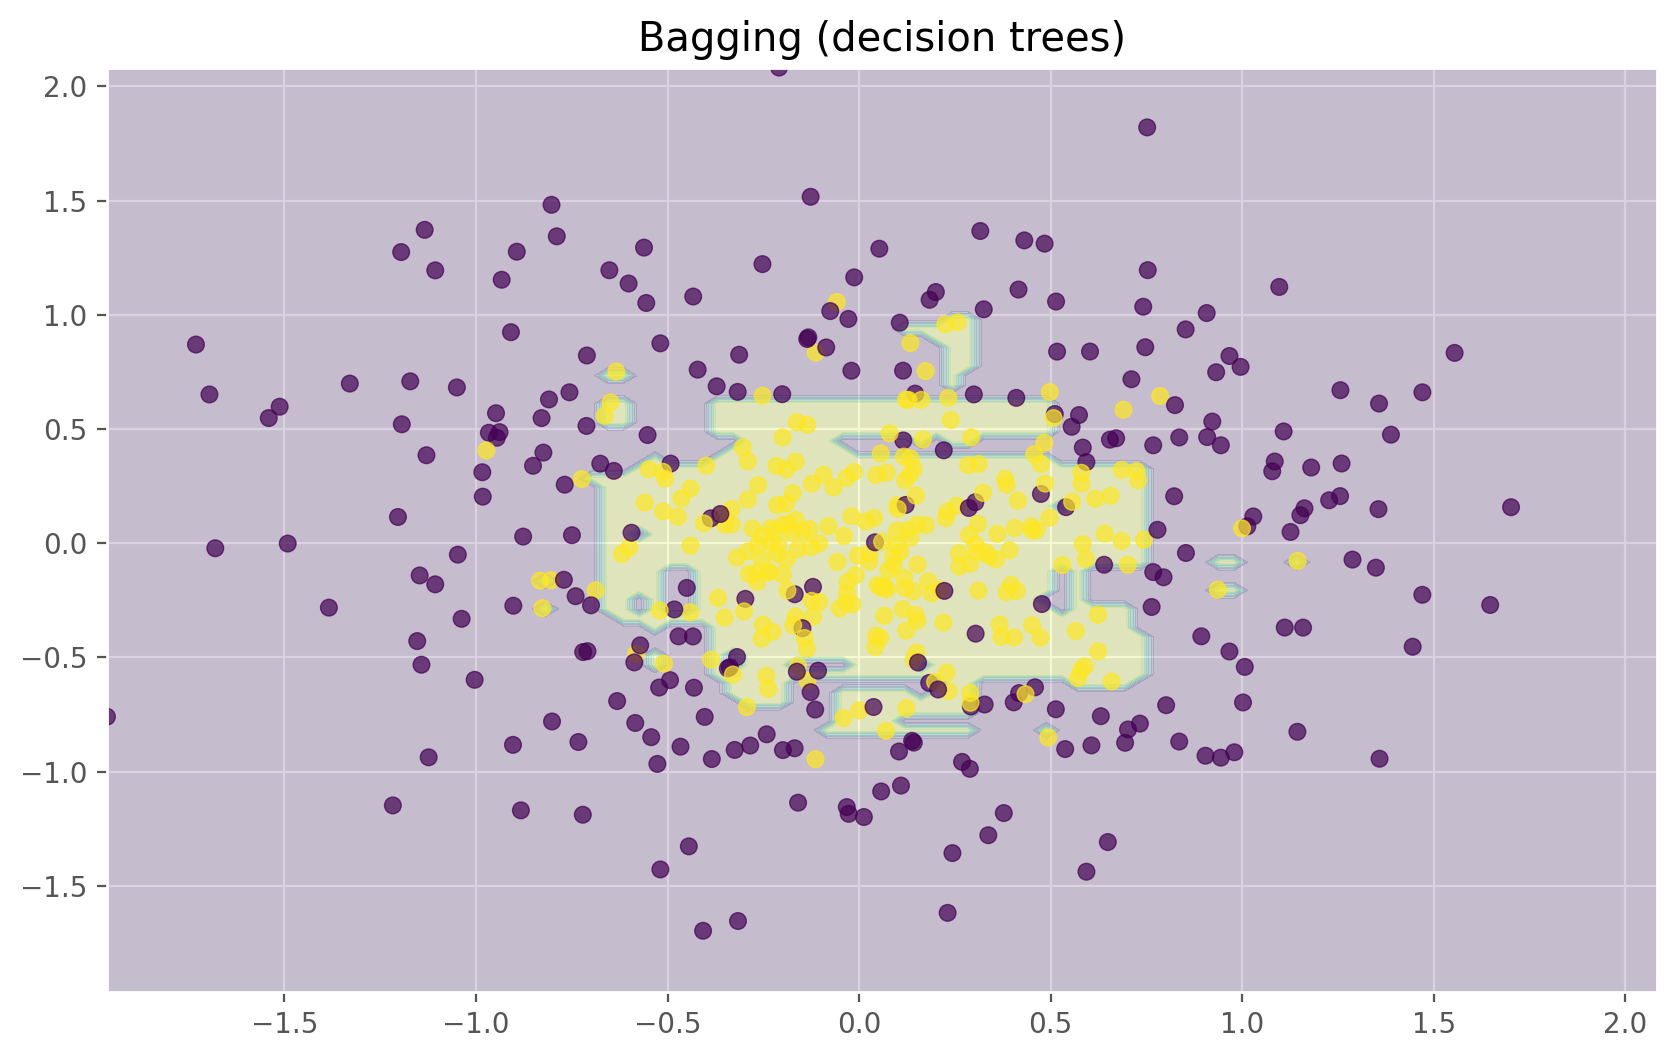

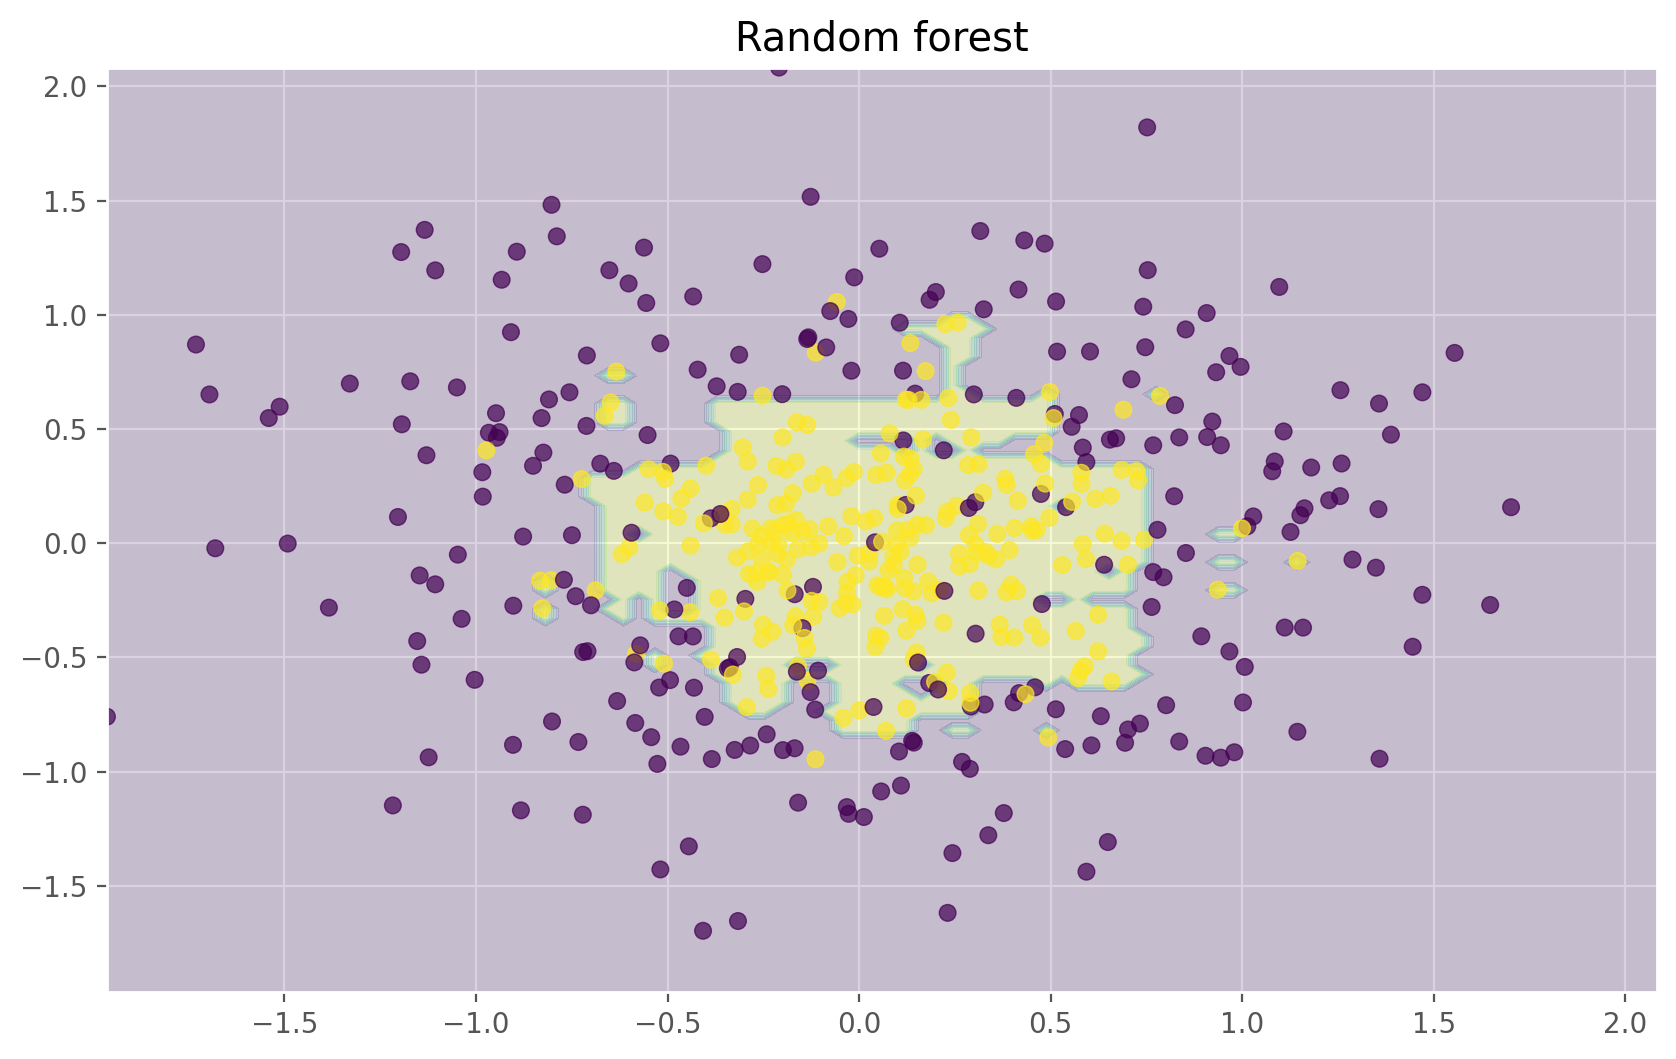

In [4]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train_circles, X_test_circles, y_train_circles, y_test_circles = \
    train_test_split(X, y, test_size=0.2)

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_circles, y_train_circles)

X_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(X_range,X_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

b_dtree = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=300, random_state=42)
b_dtree.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = b_dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Bagging (decision trees)")
plt.show()

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_circles, y_train_circles)

x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

The figures above show that the decision boundary of the decision tree is quite jagged and has a lot of acute angles that suggest overfitting and a weak ability to generalize. We would have trouble making reliable predictions on new test data. In contrast, the bagging algorithm has a rather smooth boundary and has no obvious signs of overfitting.

## Parameters

Here are simplified notes that you can use for revision.

---

# Random Forest Parameters (Simple Notes)

A **Random Forest** is a collection of decision trees. These parameters control **how many trees are created** and **how each tree grows**.

---

## 1. `n_estimators`

**Meaning:** Number of decision trees in the forest.

```python
RandomForestClassifier(n_estimators=100)
```

* More trees → Usually better accuracy.
* Too many trees → Slower training and prediction.

**Default:** `100` (older versions used `10`)

**Remember:** **More trees = More votes = Better stability.**

---

## 2. `criterion`

**Meaning:** Decides how the tree chooses the best split.

### Classification

* `"gini"` → Uses Gini Impurity
* `"entropy"` → Uses Information Gain

```python
criterion="gini"
```

### Regression

* `"squared_error"` (formerly `"mse"`) → Uses Mean Squared Error
* `"absolute_error"` (formerly `"mae"`) → Uses Mean Absolute Error

**Remember:**

* Classification → Gini / Entropy
* Regression → Squared Error / Absolute Error

---

## 3. `max_features`

**Meaning:** Number of features considered when searching for the best split.

Example:

Suppose your dataset has

```text
10 features
```

If

```python
max_features=3
```

the tree randomly picks **3 features** and finds the best split only among those.

Possible values:

* Integer

```python
max_features=5
```

* Fraction

```python
max_features=0.5
```

(50% of features)

* `"sqrt"`

Uses

[
\sqrt{\text{number of features}}
]

* `"log2"`

Uses

[
\log_2(\text{number of features})
]

**Why?**

Randomly selecting features makes different trees less similar, which improves the forest.

---

## 4. `max_depth`

**Meaning:** Maximum depth of each tree.

```python
max_depth=5
```

Example:

```text
Root
 |
 |--Depth 1
      |
      |--Depth 2
            |
            |--Depth 3
```

Small depth

* Simpler tree
* Faster
* Less overfitting

Large depth

* Complex tree
* Can overfit

---

## 5. `min_samples_split`

**Meaning:** Minimum number of samples needed before a node can split.

Example

```text
Node has

8 samples
```

If

```python
min_samples_split=10
```

No split occurs.

If

```python
min_samples_split=2
```

Split is allowed.

Higher value → Simpler tree.

---

## 6. `min_samples_leaf`

**Meaning:** Minimum number of samples allowed in each leaf.

Example

Bad split

```text
Left leaf : 1 sample

Right leaf : 99 samples
```

If

```python
min_samples_leaf=5
```

This split is not allowed.

Higher value reduces overfitting.

---

## 7. `min_weight_fraction_leaf`

Same idea as `min_samples_leaf`, but uses **sample weights** instead of the number of samples.

Most beginners don't use this.

Default:

```python
0
```

---

## 8. `max_leaf_nodes`

Limits the total number of leaf nodes.

Example

```python
max_leaf_nodes=20
```

The tree stops growing after creating 20 leaves.

Useful for controlling model complexity.

---

## 9. `bootstrap`

```python
bootstrap=True
```

Should each tree be trained on a random sample of the training data?

* `True` ✔ (normal Random Forest)
* `False` → Every tree uses the entire dataset.

**Remember:**

Bootstrap = Random sampling **with replacement**.

---

## 10. `oob_score`

Out-of-Bag Score

```python
oob_score=True
```

Since each tree is trained on only part of the data, some samples are left out.

Those unused samples are called

**Out-of-Bag samples**

They can be used to estimate model performance without needing a separate validation set.

Usually left as

```python
False
```

unless you specifically want an OOB estimate.

---

## 11. `n_jobs`

Controls CPU usage.

```python
n_jobs=1
```

Uses one CPU core.

```python
n_jobs=-1
```

Uses **all CPU cores**.

Faster training.

---

## 12. `random_state`

Controls randomness.

```python
random_state=42
```

Every run produces the same forest.

Useful for reproducible results.

---

## 13. `verbose`

Controls how much information is printed while training.

```python
verbose=0
```

No messages.

```python
verbose=1
```

Some progress messages.

Useful only for debugging.

---

## 14. `warm_start`

```python
warm_start=True
```

Instead of creating a brand-new forest,

keep the existing trees and **add more**.

Example

```python
rf = RandomForestClassifier(
    n_estimators=100,
    warm_start=True
)

rf.fit(X, y)

rf.set_params(n_estimators=150)

rf.fit(X, y)
```

Now the forest has

```text
150 trees
```

instead of rebuilding from scratch.

---

# Classification-only Parameter

## `class_weight`

Useful when classes are imbalanced.

Example

```text
990 Cats

10 Dogs
```

Without weights

The model mostly predicts

```text
Cat
```

because cats dominate.

Using

```python
class_weight="balanced"
```

gives more importance to the minority class.

Possible values

```python
None
```

No weighting.

```python
"balanced"
```

Automatic balancing.

```python
{0:1, 1:5}
```

Manual weights.

---

# Quick Revision Table

| Parameter                  | Simple Meaning                                                          |
| -------------------------- | ----------------------------------------------------------------------- |
| `n_estimators`             | Number of trees                                                         |
| `criterion`                | How the best split is chosen                                            |
| `max_features`             | Number of features checked at each split                                |
| `max_depth`                | Maximum depth of a tree                                                 |
| `min_samples_split`        | Minimum samples needed to split a node                                  |
| `min_samples_leaf`         | Minimum samples allowed in a leaf                                       |
| `min_weight_fraction_leaf` | Minimum weighted fraction required in a leaf (used with sample weights) |
| `max_leaf_nodes`           | Maximum number of leaf nodes                                            |
| `bootstrap`                | Use random sampling with replacement for each tree                      |
| `oob_score`                | Evaluate using out-of-bag samples                                       |
| `n_jobs`                   | Number of CPU cores to use (`-1` = all cores)                           |
| `random_state`             | Seed for reproducible results                                           |
| `verbose`                  | Controls training output messages                                       |
| `warm_start`               | Add more trees to an existing forest instead of rebuilding it           |
| `class_weight`             | Give more importance to certain classes (classification only)           |

## Easy way to remember the most important ones

In practice, the parameters you'll tune most often are:

* **`n_estimators`** → How many trees?
* **`max_depth`** → How deep can each tree grow?
* **`max_features`** → How many features can a tree consider at each split?
* **`min_samples_split`** → When is a node allowed to split?
* **`min_samples_leaf`** → How small can a leaf become?
* **`bootstrap`** → Should each tree use a random bootstrap sample?
* **`random_state`** → Make results reproducible.
* **`class_weight`** → Handle imbalanced classes (classification only).

These eight parameters account for the majority of Random Forest tuning in real-world machine learning projects.


## Practice with Random Forest in real problem

In this example we will look at predicting customer churn. This is a classification problem, so we will use accuracy for model evaluation.

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(DATA_PATH + "telecom_churn.csv")

# Choose numeric features
cols = []
for i in df.columns:
    if (df[i].dtype == "float64") or (df[i].dtype == 'int64'):
        cols.append(i)

# Divide the dataset into input and target
X, y = df[cols].copy(), np.asarray(df["Churn"],dtype='int8')

# Initialize a stratified split of our dataset for the validation process
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the classifier with the default parameters
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)

# train it on the training set
results = cross_val_score(rfc, X, y, cv=skf)

# Evaluate the accuract in the test set
print("CV accuracy score: {:.2f}%".format(results.mean() * 100))

CV accuracy score: 92.50%


We have accuracy equal to 91.18%. Now, let’s try to improve this result, and take a look at the behavior of the learning curves when we change the basic parameters.

In [6]:
# Initilize the validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create lists to save the values of accuracy of training and test sets
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
tree_grid = [5,10,15,20,30,50,75,100]

for ntrees in tree_grid:
    rfc = RandomForestClassifier(n_estimators=ntrees, random_state=42, n_jobs=-1)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best CV accuracy is {:.2f}% with {} trees".format(max(test_acc.mean(axis=1))*100,
                                                        tree_grid[np.argmax(test_acc.mean(axis=1))]))

Best CV accuracy is 92.50% with 100 trees


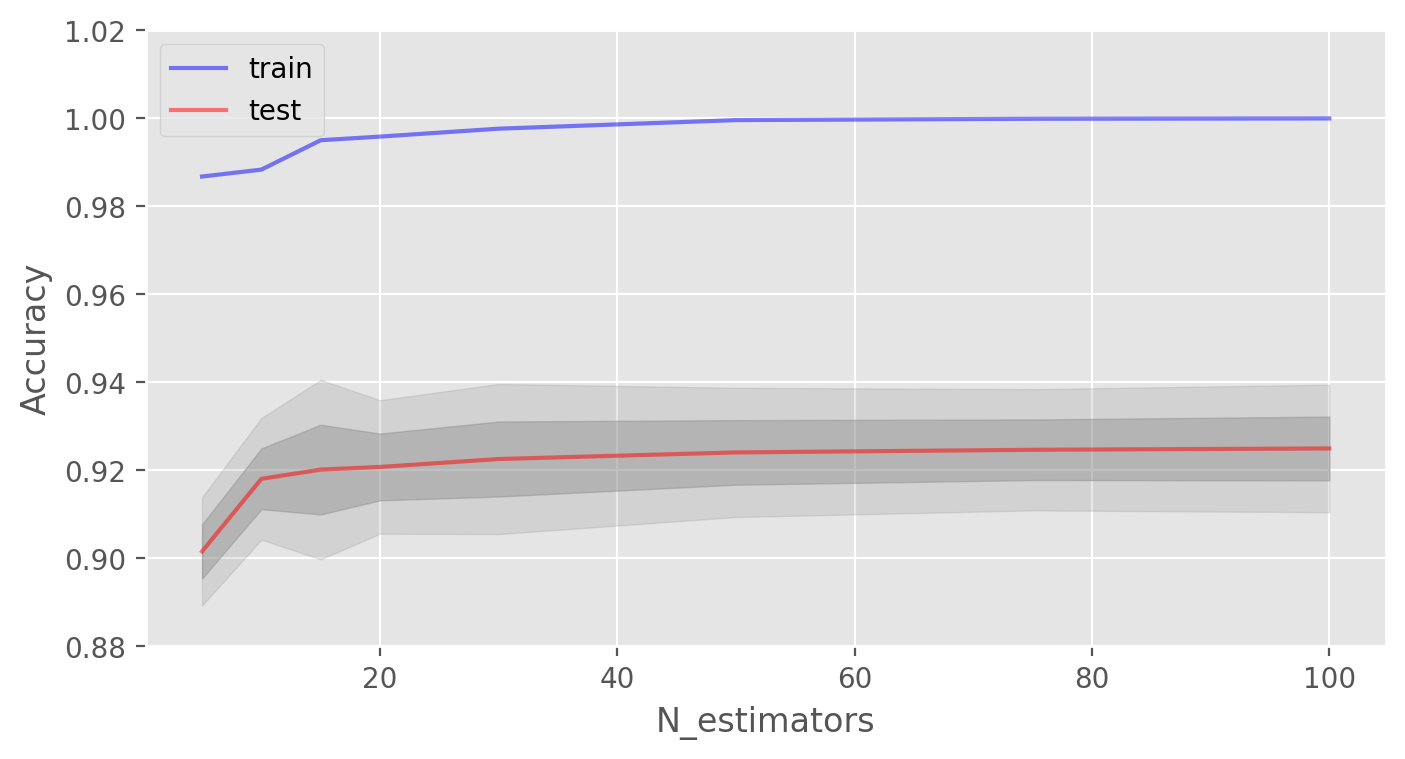

In [7]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(tree_grid, train_acc.mean(axis=1), alpha=0.5, color="blue", label="train")
ax.plot(tree_grid, test_acc.mean(axis=1), alpha=0.5, color="red", label="test")
# fills between the mean and standard deviation like "Most runs achieved accuracies around 0.90 ± 0.02."
ax.fill_between(tree_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(tree_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
# set y limit
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("N_estimators");

As you can see, when a certain number of trees is reached, our accuracy on the test set is very close to the asymptote. You can decide by yourself which value would be the optimal number of trees for your problem.
The figures also show that we achieved 100% accuracy on the training set, which tells us that we overfit. In order to avoid overfitting, we need to add regularization parameters to our model.

Best CV accuracy is 92.44% with 24 max_depth


Text(0.5, 0, 'Max_depth')

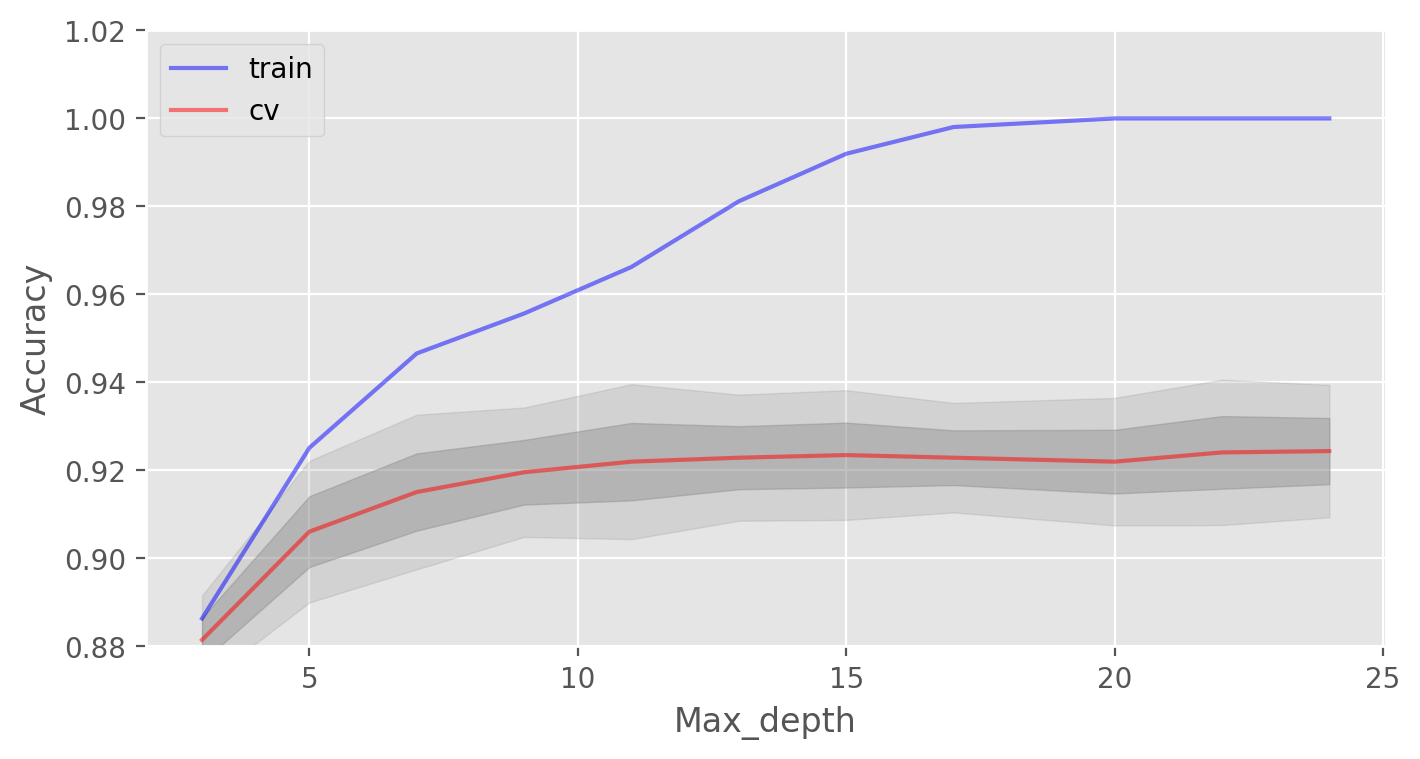

In [8]:
# We will start with the maximum depth of trees max_depth and fix the number of trees at 100

train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_depth_grid = [3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for max_depth in max_depth_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=max_depth)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X,y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best CV accuracy is {:.2f}% with {} max_depth".format(max(test_acc.mean(axis=1))*100,
                                                        max_depth_grid[np.argmax(test_acc.mean(axis=1))]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_depth_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(max_depth_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_depth_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_depth")

Parameter max_depth copes well with the regularization of our model and it does not overfit as badly as before. The model accuracy has increased slightly.

In [9]:
# Another important parameter worth tuning is min_samples_leaf. It also contributes to regularization.
# Create lists to save accuracy values on the training and test sets
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
min_samples_leaf_grid = [1, 3, 5, 7, 9, 11, 13, 15, 17, 20, 22, 24]

for min_samples_leaf in min_samples_leaf_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 min_samples_leaf=min_samples_leaf)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best CV accuracy is {:.2f}% with {} min_samples_leaf".format(max(test_acc.mean(axis=1))*100,
                                                        min_samples_leaf_grid[np.argmax(test_acc.mean(axis=1))]))

Best CV accuracy is 92.50% with 1 min_samples_leaf


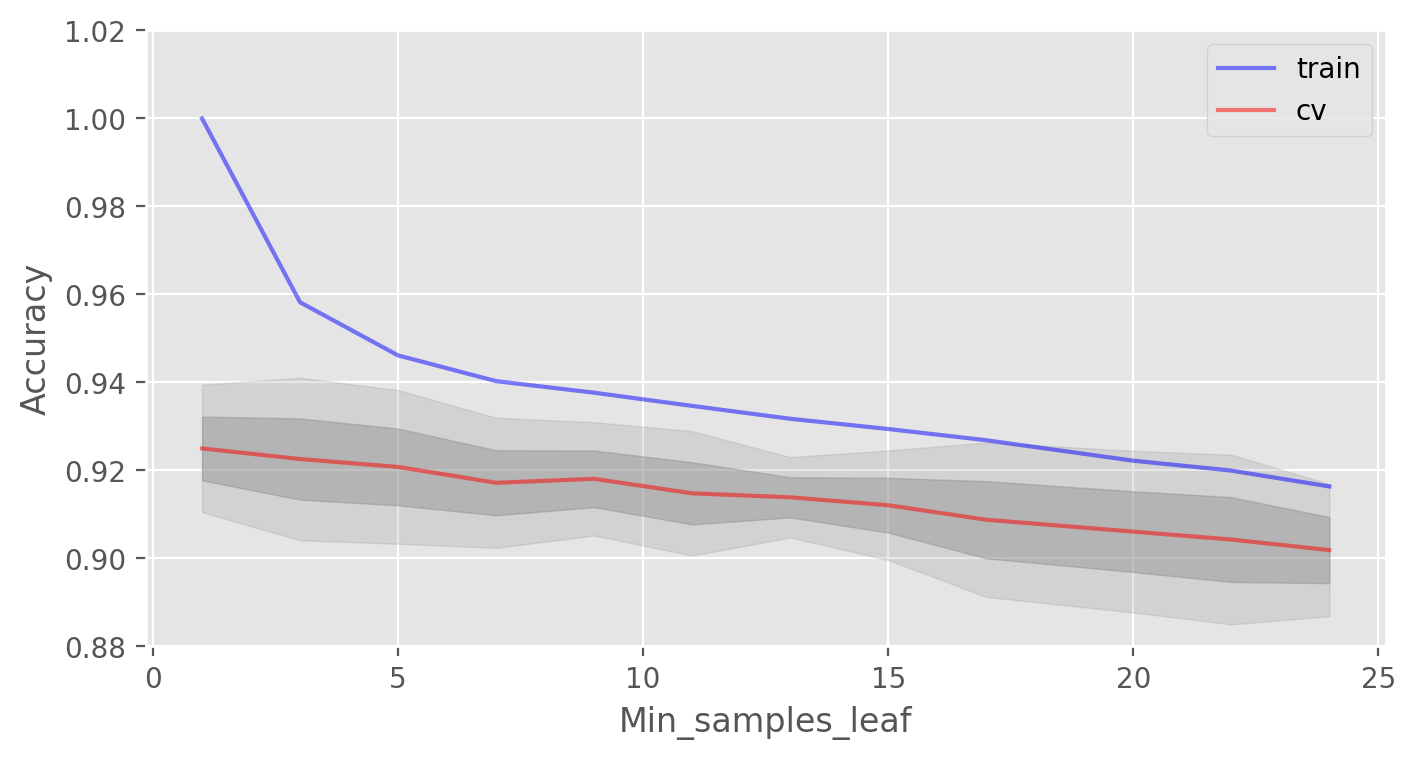

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(min_samples_leaf_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(min_samples_leaf_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(min_samples_leaf_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Min_samples_leaf");

In this case, we do not see an improvement in accuracy on the validation set, but we significantly reduce the overfitting down to 2% while keeping the accuracy at about 92%.

Let’s consider the parameter max_features. For classification, the value 
 (the total number of features) is typically used as the default choice. Let’s check whether it would be optimal to use 4 features in our case:

Best CV accuracy is 92.50% with 4 max_features


Text(0.5, 0, 'Max_features')

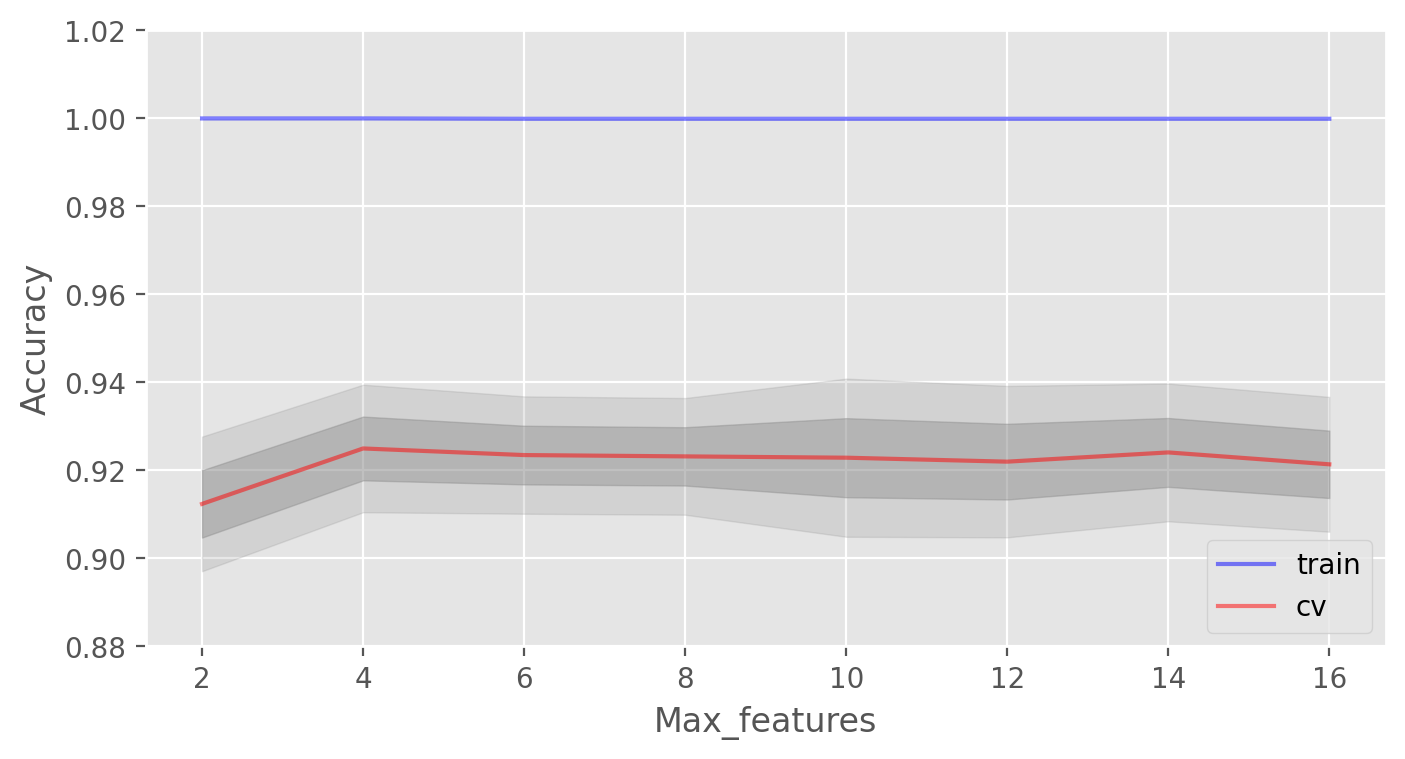

In [14]:
# Create lists to save accuracy values on the training and test sets
train_acc = []
test_acc = []
temp_train_acc = []
temp_test_acc = []
max_features_grid = [2, 4, 6, 8, 10, 12, 14, 16]

for max_features in max_features_grid:
    rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                 max_features=max_features)
    temp_train_acc = []
    temp_test_acc = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]
        rfc.fit(X_train, y_train)
        temp_train_acc.append(rfc.score(X_train, y_train))
        temp_test_acc.append(rfc.score(X_test, y_test))
    train_acc.append(temp_train_acc)
    test_acc.append(temp_test_acc)

train_acc, test_acc = np.asarray(train_acc), np.asarray(test_acc)
print("Best CV accuracy is {:.2f}% with {} max_features".format(max(test_acc.mean(axis=1))*100,
                                                        max_features_grid[np.argmax(test_acc.mean(axis=1))]))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(max_features_grid, train_acc.mean(axis=1), alpha=0.5, color='blue', label='train')
ax.plot(max_features_grid, test_acc.mean(axis=1), alpha=0.5, color='red', label='cv')
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - test_acc.std(axis=1),
                test_acc.mean(axis=1) + test_acc.std(axis=1), color='#888888', alpha=0.4)
ax.fill_between(max_features_grid, test_acc.mean(axis=1) - 2*test_acc.std(axis=1),
                test_acc.mean(axis=1) + 2*test_acc.std(axis=1), color='#888888', alpha=0.2)
ax.legend(loc='best')
ax.set_ylim([0.88,1.02])
ax.set_ylabel("Accuracy")
ax.set_xlabel("Max_features")

In our case, the optimal number of features is equal to 10. This is the value at which the best result is achieved.

We have seen how the learning curves change with different values of the basic parameters. Now, let’s use GridSearch to find the optimal parameters for our example:


In [12]:
# Initialize the set of parameters for exhaustive search and fit
parameters = {'max_features': [4, 7, 10, 13],
              'min_samples_leaf': [1, 3, 5, 7],
              'max_depth': [5, 10, 15, 20]}
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gcv = GridSearchCV(rfc, parameters, n_jobs=-1, cv=skf, verbose=1)
gcv.fit(X, y)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'max_features': [4, 7, ...], 'min_samples_leaf': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [13]:
gcv.best_params_, gcv.best_score_

({'max_depth': 20, 'max_features': 10, 'min_samples_leaf': 3},
 np.float64(0.925596661128895))

## 4. Variance and Decorrelation

## 7. Similarities between Random Forest and k-Nearest Neighbors

This is one of the coolest interpretations of Random Forests. It's saying:

> **A Random Forest is secretly acting like a k-Nearest Neighbors (k-NN) algorithm.**

That sounds surprising, but let's unpack it.

---

# Step 1: Recall how k-NN works

Suppose you want to predict the price of a house.

A new house comes in:

```text
New House
Bedrooms = 3
Area = 1800
```

k-NN says:

> Find the most similar houses in the training data.

Maybe it finds

```text
House A → $300k
House B → $320k
House C → $310k
```

Prediction:

```
(300 + 320 + 310)/3 = 310k
```

So k-NN predicts using **nearby examples**.

---

# Step 2: How does a Random Forest predict?

Consider just **one tree**.

Suppose the tree splits like

```text
          Root
         Area<2000?
        /          \
      Yes          No
```

Then

```text
Bedrooms<4?
```

Eventually we reach a leaf.

Suppose the leaf contains these training examples:

```text
Customer 5
Customer 18
Customer 31
Customer 42
```

Now a new customer arrives.

The tree sends the customer into the **same leaf**.

The prediction is simply

```
Average(targets inside leaf)
```

For example

```text
Training targets

5
8
6
9
```

Prediction

```
(5+8+6+9)/4 = 7
```

Notice something.

The tree **never compares distances**.

Instead it says

> "Everyone inside this leaf is similar."

---

# Step 3: This is exactly what the equation says

They define

[
b_n(x)
======

\sum_i
w_n(x,x_i)y_i
]

Looks scary.

Let's translate it.

It says

> Prediction of tree (n)

=

weighted average of the training labels.

That's all.

---

## What is (y_i)?

Easy.

It's the target value of training example (i).

For regression

```text
House 1 → 300k
House 2 → 250k
House 3 → 410k
```

These are the (y_i).

---

## What is (w_n(x,x_i))?

This is the important part.

They define

[
w_n(x,x_i)
==========

\frac{
[T_n(x)=T_n(x_i)]
}
{
\sum_j[T_n(x)=T_n(x_j)]
}
]

Looks horrible.

Actually it's incredibly simple.

---

The square brackets

[
[T_n(x)=T_n(x_i)]
]

mean

```
1 if true
0 if false
```

So ask

> Does training example (x_i) end up in the **same leaf** as the new point?

If yes

```
1
```

If no

```
0
```

---

Suppose this leaf contains

```text
Training point 2
Training point 5
Training point 9
```

There are three points.

Then

| Point | Same leaf? | Weight |
| ----- | ---------- | ------ |
| 1     | No         | 0      |
| 2     | Yes        | 1/3    |
| 3     | No         | 0      |
| 4     | No         | 0      |
| 5     | Yes        | 1/3    |
| 6     | No         | 0      |
| 7     | No         | 0      |
| 8     | No         | 0      |
| 9     | Yes        | 1/3    |

That's exactly what the formula computes.

Everyone outside the leaf gets weight **0**.

Everyone inside the leaf shares the weight equally.

---

# Step 4: What happens in the whole forest?

Now we have 500 trees.

Tree 1 says

```text
Points

2
5
9
```

Tree 2 says

```text
Points

5
8
10
```

Tree 3 says

```text
Points

2
5
12
```

Notice

Training point **5** appears again and again.

That means

> Tree after tree thinks point 5 is similar to the new sample.

Its weight increases.

---

Eventually the forest prediction becomes

[
a(x)
====

\sum_i
(\text{average weight})
y_i
]

So each training point gets a weight depending on

> **How often it lands in the same leaf as the new point across all the trees.**

---

# Step 5: Why is this like k-NN?

k-NN defines similarity by

> Euclidean distance.

Random Forest defines similarity by

> **How often two points end up in the same leaf.**

Example

Suppose

```text
Tree 1

A and B together
```

Tree 2

```text
A and B together
```

Tree 3

```text
A and B together
```

Tree 4

```text
A and B together
```

Then

A and B are considered

```
very similar
```

Another point C

```text
never shares leaves with A
```

Then

```
A and C are not similar
```

So Random Forest creates its own notion of "distance."

Instead of measuring

```
Euclidean distance
```

it measures

```
Leaf co-occurrence
```

---

# Step 6: Why are leaf numbers useful as features?

Suppose one tree has leaves

```text
Leaf 1
Leaf 2
Leaf 3
Leaf 4
```

A sample might end up in

```text
Leaf 3
```

Another tree

```text
Leaf 7
```

Another

```text
Leaf 2
```

Now instead of describing the sample as

```text
Age = 24
Income = 60k
```

you can describe it as

```text
Tree1 → Leaf3
Tree2 → Leaf7
Tree3 → Leaf2
...
```

This vector

```text
(3,7,2,...)
```

is a new feature representation.

Why is it useful?

Because each leaf represents a **complex region of the feature space**.

For example,

Leaf 3 might correspond to

```text
Age > 30

AND

Income < 70k

AND

Education = Masters

AND

Credit score > 650
```

The single value

```text
Leaf 3
```

captures all of those nonlinear conditions at once.

---

## The big picture

The key insight is:

* A decision tree predicts by averaging the target values of the training samples in the **same leaf**.
* A Random Forest averages this process across many trees.
* A training example becomes **important** if it repeatedly lands in the same leaf as the query point.
* Therefore, Random Forest defines similarity not by geometric distance (like k-NN), but by **how often two samples end up together in the same leaf**.

This "leaf-based similarity," often called the **proximity measure** of a Random Forest, is one of its most elegant ideas. It allows the forest to discover complex, nonlinear notions of similarity that simple distance metrics (like Euclidean distance) often miss.
